In [1]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg


import argparse
import sys
from pathlib import Path
from scipy.ndimage import uniform_filter
from scipy.signal import wiener as scipy_wiener

%pip install scikit-image
from skimage import io, img_as_float, color, img_as_float32
from scipy.ndimage import gaussian_filter
from scipy.signal import convolve2d, fftconvolve
from skimage.restoration import richardson_lucy
from scipy.ndimage import sobel
from skimage import img_as_ubyte

  Using cached scikit_image-0.26.0-cp311-cp311-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (15 kB)
  Using cached imageio-2.37.3-py3-none-any.whl.metadata (9.7 kB)
  Using cached tifffile-2026.3.3-py3-none-any.whl.metadata (31 kB)
  Using cached lazy_loader-0.5-py3-none-any.whl.metadata (5.9 kB)
Using cached scikit_image-0.26.0-cp311-cp311-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl (13.7 MB)
Using cached imageio-2.37.3-py3-none-any.whl (317 kB)
Using cached lazy_loader-0.5-py3-none-any.whl (8.0 kB)
Using cached tifffile-2026.3.3-py3-none-any.whl (243 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-image] [scikit-image]
Note: you may need to restart the kernel to use updated packages.


## Noise: Poission

In [2]:
def noise_poission(image, peak=10.0):
    image_data = (np.array(image)).astype(np.float64)
    h,w,c = image_data.shape

    image_gray = np.mean(image_data, axis=2, keepdims=True)
    
    scaled_gray = image_gray * (peak / 255.0)
    
    noisy_gray = np.random.poisson(scaled_gray).astype(np.float64)

    noisy_gray_rescaled = noisy_gray *  (255.0 / peak)
    diff = noisy_gray_rescaled - image_gray
    noisy_image = image_data + diff
    
    # Convert back to 0-255 uint8 format
    noisy_img =  Image.fromarray((np.clip(noisy_image, 0, 255)).astype(np.uint8))
    return noisy_img

## Blur: Gaussian

In [3]:
#making kernel
def make_gaussian_kernel(size,sigma):
    ax = np.linspace(-(size-1)/2, (size-1)/2, size)
    gauss = 1 / (2.0 * np.pi * sigma**2) *np.exp(-0.5 *np.square(ax) / np.square(sigma))
    kernel = np.outer(gauss, gauss)
    return(kernel/kernel.sum())


def appy_gaussian_blur(image, kernel_size=5, sigma=1.0):
    image_data = np.array(image)
    kernel = make_gaussian_kernel(kernel_size,sigma)
    kernel_3d = kernel[:, :, np.newaxis]
    h, w, c = image_data.shape
    pad = kernel_size // 2

    padded_img = np.pad(image_data, ((pad,pad), (pad,pad), (0,0)), mode='edge')
    blurred = np.zeros_like(image_data)

    for i in range(h):
        for j in range(w):
            region = padded_img[i:i+kernel_size, j:j+kernel_size, :]
            blurred[i,j] = np.sum(region * kernel_3d, axis=(0,1))
    blurred = Image.fromarray(blurred)
    return blurred

## Blurring the Photos

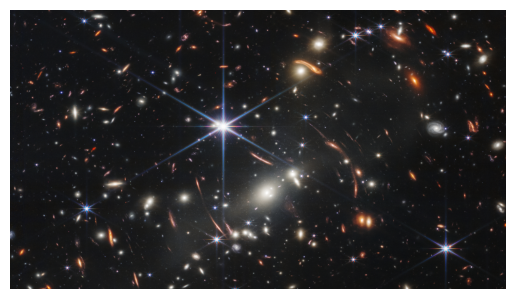

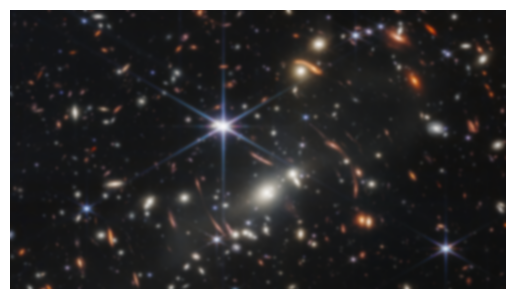

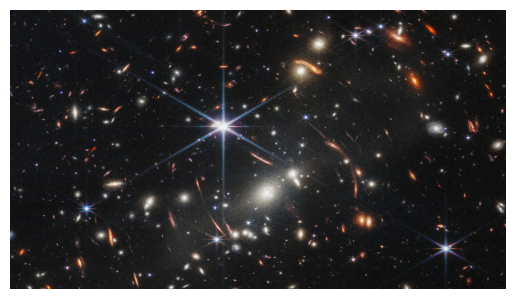

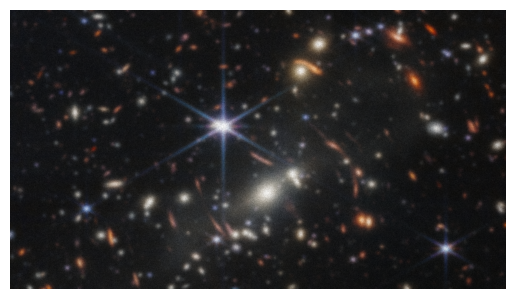

In [4]:
#blurred image
original = Image.open('stars_regular.jpg')

#noisy image
noisy = noise_poission(original,75)

#blurred image
blurred = appy_gaussian_blur(original, 51, 5)


#noise on top of blur
both = noise_poission(blurred,75)


#show images
plt.imshow(original)
plt.axis('off')
plt.show()

plt.imshow(blurred)
plt.axis('off')
plt.show()

plt.imshow(noisy)
plt.axis('off')
plt.show()

plt.imshow(both)
plt.axis('off')
plt.show()

#save images if necessary
# noisy.save('stars_noise.jpg')
# blurred.save('stars_blurred.jpg')
# both.save('stars_both.jpg')

## Richardson_Lucy Deconvolution

In [6]:
def richardsonLucy(image, psf, iterations):
    psf = psf / np.maximum(psf.sum(), 1e-8)
    psflipped = np.flip(psf)
    est = np.full(image.shape, 0.5, dtype=np.float32)
    for _ in range(iterations):
        estblur = fftconvolve(est, psf, mode='same')
        ratio = image / np.maximum(estblur, 1e-10)
        correction = fftconvolve(ratio, psflipped, mode='same')
        est *= correction
    return est

In [7]:
def edgeEstimatedPsf(image, point=15):
    grad = np.hypot(sobel(image, axis=0), sobel(image, axis=1))
    y, x = np.unravel_index(grad.argmax(), grad.shape)
    h = point // 2
    if y - h < 0 or y + h + 1 > image.shape[0] or \
       x - h < 0 or x + h + 1 > image.shape[1]:
        return gaussianFallbackPsf(point)      
    patch = image[y-h : y+h+1, x-h : x+h+1]
    if patch.shape != (point, point):
        return gaussianFallbackPsf(point)
    psf = np.abs(patch)
    psf = np.maximum(psf, 1e-8)
    psf /= psf.sum()
    return psf

def gaussianFallbackPsf(point=15, sigma=2.0):
    coords = np.linspace(-(point // 2), point // 2, point)
    x, y = np.meshgrid(coords, coords)
    psf = np.exp(-(x**2 + y**2) / (2 * sigma**2))
    psf /= psf.sum()
    return psf

In [8]:
def richardsonLucy_color(image, psf, iterations):
    if image.ndim==2:
        return richardsonLucy(image, psf, iterations)
    channels=[richardsonLucy(image[:, :, c], psf, iterations) for c in range(image.shape[2])]
    return np.stack(channels, axis=2)

In [9]:
blurred_array = img_as_float32(blurred)
noisy_array = img_as_float32(noisy)
both_array = img_as_float32(both)

In [10]:
sgreyblur=color.rgb2gray(blurred_array)
sgreynoisy=color.rgb2gray(noisy_array)
sgreyconv=color.rgb2gray(both_array)

In [11]:
spsfblurredest = edgeEstimatedPsf(sgreyblur)
spsfnoisyest   = edgeEstimatedPsf(sgreynoisy)
spsfconvest    = edgeEstimatedPsf(sgreyconv)

In [12]:
rl_blurred_final = richardsonLucy_color(blurred_array,    spsfblurredest, 15)
rl_noisy_final = richardsonLucy_color(noisy_array,      spsfnoisyest,   15)
rl_both_final = richardsonLucy_color(both_array, spsfconvest,    15)

In [13]:
rl_blurred_array = img_as_ubyte(np.clip(rl_blurred_final, 0, 1))
rl_blurred = Image.fromarray(rl_blurred_array)

rl_noisy_array = img_as_ubyte(np.clip(rl_noisy_final, 0, 1))
rl_noisy = Image.fromarray(rl_noisy_array)

rl_both_array = img_as_ubyte(np.clip(rl_both_final, 0, 1))
rl_both = Image.fromarray(rl_both_array)

In [14]:
#using builtin
schannels = [richardson_lucy(blurred_array[:, :, c], spsfblurredest, num_iter=15) for c in range(3)]
sdeconvolved_blurred = np.stack(schannels, axis=2)
schannels2 = [richardson_lucy(both_array[:, :, c], spsfconvest, num_iter=15) for c in range(3)]
sdeconvolved_both = np.stack(schannels2, axis=2)
schannels3 = [richardson_lucy(noisy_array[:, :, c], spsfnoisyest, num_iter=15) for c in range(3)]
sdeconvolved_noisy = np.stack(schannels3, axis=2)

In [15]:
rl_blurred_array_builtin = img_as_ubyte(np.clip(sdeconvolved_blurred, 0, 1))
rl_blurred_builtin = Image.fromarray(rl_blurred_array_builtin)

rl_noisy_array_builtin = img_as_ubyte(np.clip(sdeconvolved_noisy, 0, 1))
rl_noisy_builtin = Image.fromarray(rl_noisy_array_builtin)

rl_both_array_builtin = img_as_ubyte(np.clip(sdeconvolved_both, 0, 1))
rl_both_builtin = Image.fromarray(rl_both_array_builtin)

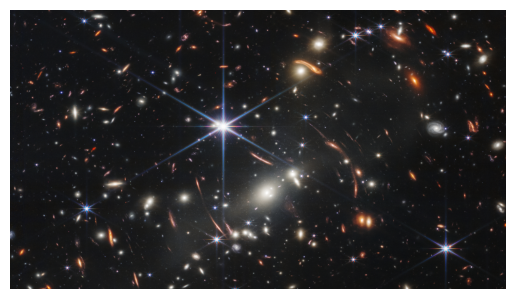

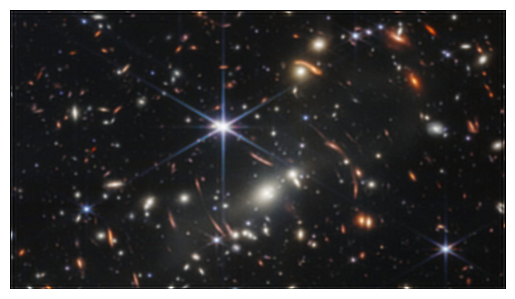

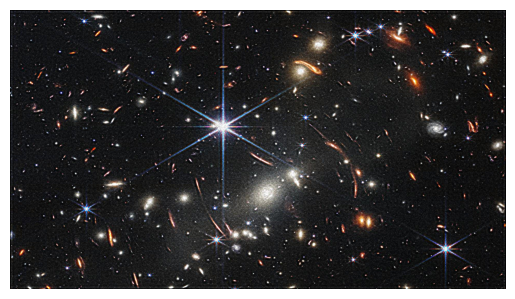

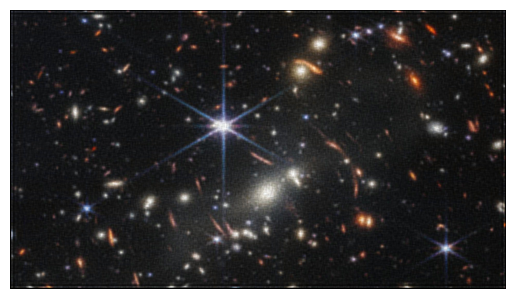

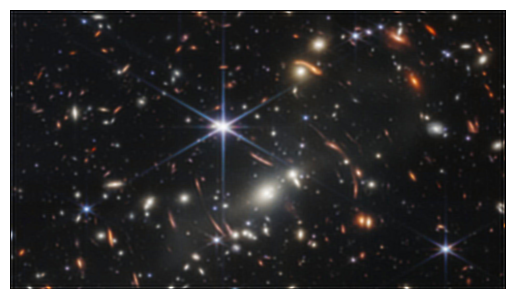

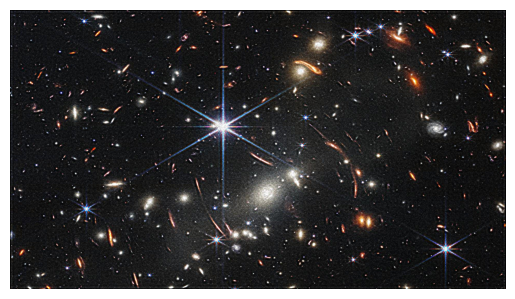

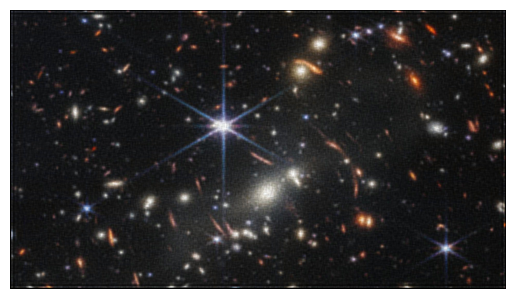

In [16]:
#save if desired
# rl_blurred.save('rl_blurred.png')
# rl_noisy.save('rl_noisy.png')
# rl_both.save('rl_both.png')

# rl_blurred_builtin.save('rl_blurred_builtin.png')
# rl_noisy_builtin.save('rl_noisy_builtin.png')
# rl_both_builtin.save('rl_both_builtin.png')

# show images
plt.imshow(original)
plt.axis('off')
plt.show()

plt.imshow(rl_blurred)
plt.axis('off')
plt.show()

plt.imshow(rl_noisy)
plt.axis('off')
plt.show()

plt.imshow(rl_both)
plt.axis('off')
plt.show()

plt.imshow(rl_blurred_builtin)
plt.axis('off')
plt.show()

plt.imshow(rl_noisy_builtin)
plt.axis('off')
plt.show()

plt.imshow(rl_both_builtin)
plt.axis('off')
plt.show()

## Wiener Method

### Our model

In [3]:
# PSF generator
def gaussian_psf(size: int, sigma: float) -> np.ndarray:
    ax = np.arange(size) - size // 2
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-(xx ** 2 + yy ** 2) / (2 * sigma ** 2))
    return kernel / kernel.sum()

# Wiener filter
def wiener_filter_channel(channel: np.ndarray, psf: np.ndarray, K: float) -> np.ndarray:
    """
    channel: 2-D float array, values in [0, 1]
    psf: 2-D PSF kernel
    K: noise-to-signal power ratio

    Returns: restored channel as float array in [0, 1].
    """
    rows, cols = channel.shape

    psf_padded = np.zeros((rows, cols))
    ph, pw = psf.shape
    psf_padded[:ph, :pw] = psf
    psf_padded = np.roll(psf_padded, -ph // 2, axis=0)
    psf_padded = np.roll(psf_padded, -pw // 2, axis=1)

    H = np.fft.fft2(psf_padded)
    G = np.fft.fft2(channel)

    W = np.conj(H) / (np.abs(H) ** 2 + K)
    F_hat = W * G

    restored = np.real(np.fft.ifft2(F_hat))
    return np.clip(restored, 0.0, 1.0)

def wiener_deconvolve(image: np.ndarray, psf: np.ndarray, K: float) -> np.ndarray:
    """
    image: H×W or H×W×C float array in [0, 1]
    psf: 2-D PSF kernel
    K: noise-to-signal power ratio

    Returns: restored image array (same shape as input).
    """
    if image.ndim == 2:
        return wiener_filter_channel(image, psf, K)

    restored = np.zeros_like(image)
    for c in range(image.shape[2]):
        restored[:, :, c] = wiener_filter_channel(image[:, :, c], psf, K)
    return restored

# K estimator
def estimate_K(image: np.ndarray, peak: float = 75.0) -> float:
    """
    image: H×W×C or H×W float array
    peak: max mean photon count (default 75)

    Returns: K 
    """
    if image.ndim == 3:
        gray = 0.299 * image[:, :, 0] + 0.587 * image[:, :, 1] + 0.114 * image[:, :, 2]
    else:
        gray = image.copy()

    photon_counts = gray * peak

    local_mean = uniform_filter(photon_counts, size=5)

    noise_var = np.mean(local_mean) / (peak ** 2)

    signal_var = np.var(gray)

    K = noise_var / max(signal_var, 1e-10)
    return float(np.clip(K, 1e-5, 1.0))

### Built in function


In [4]:
def wiener_deconvolve_builtin(image: np.ndarray, mysize: int = 5) -> np.ndarray:
    """
    image: H×W or H×W×C float array
    mysize: size of the local neighbourhood window (default 5)

    Returns:restored image array
    """
    if image.ndim == 2:
        return np.clip(scipy_wiener(image, mysize=mysize), 0.0, 1.0)

    restored = np.zeros_like(image)
    for c in range(image.shape[2]):
        restored[:, :, c] = np.clip(
            scipy_wiener(image[:, :, c], mysize=mysize), 0.0, 1.0
        )
    return restored

### Helper Utilties

In [5]:
def load_image(path: str) -> np.ndarray:
    img = Image.open(path).convert("RGB")
    return np.asarray(img, dtype=np.float32) / 255.0

# For changing params
def build_parser() -> argparse.ArgumentParser:
    p = argparse.ArgumentParser(description="Wiener image deconvolution.", formatter_class=argparse.ArgumentDefaultsHelpFormatter)

    p.add_argument("input", help="Path to input image (JPEG / PNG / TIFF ...)")

    p.add_argument("-o", "--output", default=None)

    p.add_argument("--psf_size", type=int, default=51)

    p.add_argument("--psf_sigma", type=float, default=5.0)

    p.add_argument("--K", type=float, default=None)

    p.add_argument("--peak", type=float, default=75.0)

    p.add_argument("--noise_only", action="store_true")

    p.add_argument("--use_builtin", action="store_true")

    p.add_argument("--builtin_size", type=int, default=5)

    return p

In [6]:
def main(args_list=None):
    parser = build_parser()
    args = parser.parse_args(args_list)
    input_path = Path(args.input)
    if not input_path.exists():
        raise FileNotFoundError(f"File not found: {input_path}")

    print(f"... Loading  {input_path}")
    image = load_image(str(input_path))
    
    if args.noise_only:
        psf = np.zeros((args.psf_size, args.psf_size))
        psf[args.psf_size // 2, args.psf_size // 2] = 1.0
        print("... Using delta PSF (noise-only mode)")
    else:
        psf = gaussian_psf(args.psf_size, args.psf_sigma)
        print(f"... Building Gaussian PSF  size={args.psf_size}  sigma={args.psf_sigma}")

    if args.K is None:
        K = estimate_K(image, peak=args.peak)
        print(f"... Auto-estimated K = {K:.6f}")
    else:
        K = args.K
        print(f"... Using K = {K}")

    if args.use_builtin:
        print(f"... Applying scipy Wiener filter  window={args.builtin_size}")
        restored = wiener_deconvolve_builtin(image, mysize=args.builtin_size)
    else:
        print(f"... Applying written Wiener filter  K={K}")
        restored = wiener_deconvolve(image, psf, K)
    print("[✓] Done.")

    uint8 = (np.clip(restored, 0.0, 1.0) * 255).astype(np.uint8)
    restored_img = Image.fromarray(uint8)
    
    return(restored_img)
    

... Loading  stars_blurred.jpg
... Building Gaussian PSF  size=51  sigma=5.0
... Using K = 0.13533528323
... Applying written Wiener filter  K=0.13533528323
[✓] Done.
... Loading  stars_noise.jpg
... Building Gaussian PSF  size=51  sigma=5.0
... Using K = 0.116302
... Applying written Wiener filter  K=0.116302
[✓] Done.
... Loading  stars_both.jpg
... Building Gaussian PSF  size=51  sigma=5.0
... Using K = 0.145816
... Applying written Wiener filter  K=0.145816
[✓] Done.
... Loading  stars_blurred.jpg
... Building Gaussian PSF  size=51  sigma=5.0
... Auto-estimated K = 0.171142
... Applying scipy Wiener filter  window=5
[✓] Done.
... Loading  stars_noise.jpg
... Building Gaussian PSF  size=51  sigma=5.0
... Auto-estimated K = 0.116749
... Applying scipy Wiener filter  window=5
[✓] Done.
... Loading  stars_both.jpg
... Building Gaussian PSF  size=51  sigma=5.0
... Auto-estimated K = 0.145469
... Applying scipy Wiener filter  window=5
[✓] Done.


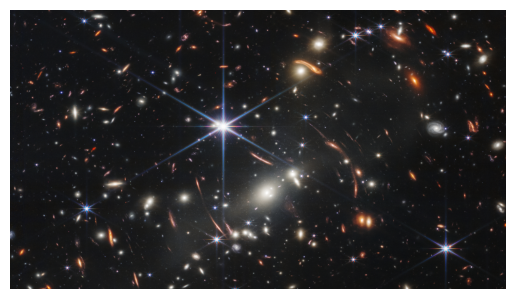

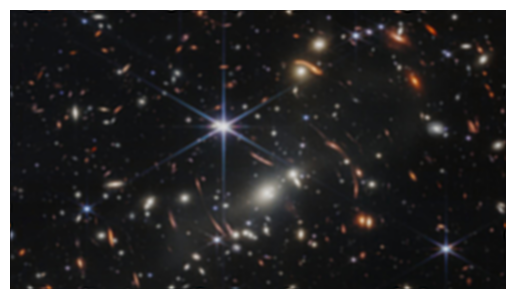

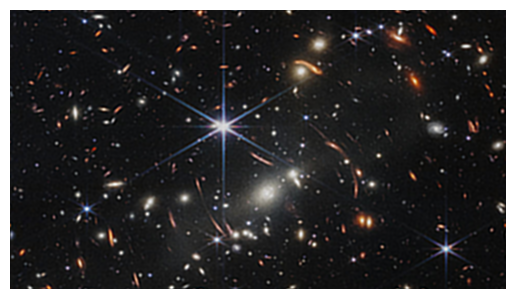

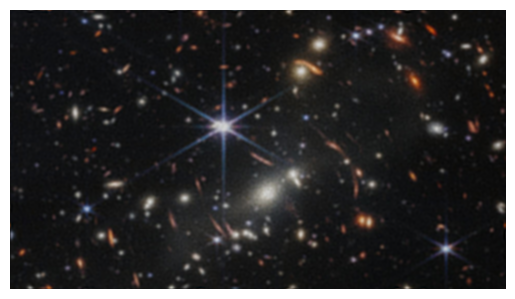

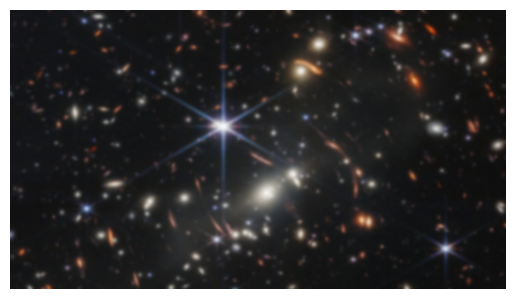

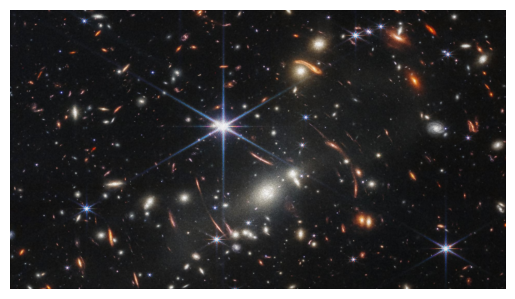

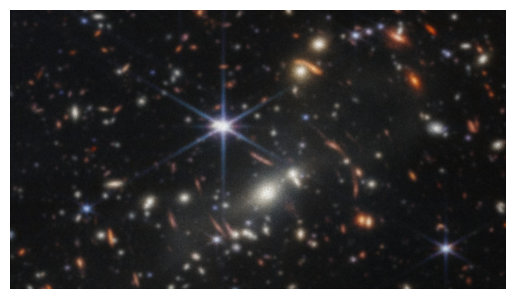

In [8]:
wiener_blurred = main(['stars_blurred.jpg', '--K','0.13533528323' ])
wiener_noisy = main(['stars_noise.jpg', '--K','0.116302' ])
wiener_both = main(['stars_both.jpg', '--K',' 0.145816 ' ])


wiener_blurred_builtin = main(['stars_blurred.jpg', '--use_builtin' ])
wiener_noisy_builtin = main(['stars_noise.jpg', '--use_builtin' ])
wiener_both_builtin = main(['stars_both.jpg', '--use_builtin' ])


#save if desired
# wiener_blurred.save('wiener_blurred.png')
# wiener_noisy.save('wiener_noisy.png')
# wiener_both.save('wiener_both.png')

# wiener_blurred_builtin.save('wiener_blurred_builtin.png')
# wiener_noisy_builtin.save('wiener_noise_builtin.png')
# wiener_both_builtin.save('wiener_both_builtin.png')

# show images
plt.imshow(original)
plt.axis('off')
plt.show()

plt.imshow(wiener_blurred)
plt.axis('off')
plt.show()

plt.imshow(wiener_noisy)
plt.axis('off')
plt.show()

plt.imshow(wiener_both)
plt.axis('off')
plt.show()

plt.imshow(wiener_blurred_builtin)
plt.axis('off')
plt.show()

plt.imshow(wiener_noisy_builtin)
plt.axis('off')
plt.show()

plt.imshow(wiener_both_builtin)
plt.axis('off')
plt.show()

## Inverse Filtering

In [2]:
def get_gaussian_kernel(size,sigma):
    ax = np.linspace(-(size-1)/2, (size-1)/2, size)
    gauss = 1 / (2.0 * np.pi * sigma**2) *np.exp(-0.5 *np.square(ax) / np.square(sigma))
    kernel = np.outer(gauss, gauss)
    return(kernel/kernel.sum())

def inverse_filtering(image, kernel_size,sigma, threshold =0.2):
    image_data = (np.array(image)).astype(np.float64)

    kernel = get_gaussian_kernel(kernel_size,sigma)

    #take 2D FFT of image and kernel (pad kernel to image)
    img_fft = np.fft.fft2(image_data)
    kernel_fft = np.fft.fft2(kernel, s=image_data.shape[:2])

    #compute inverse filter: F=G/H
    h_inverse = np.zeros_like(kernel_fft)
    indices = np.abs(kernel_fft) > threshold #avoids division by 0
    h_inverse[indices] = 1/kernel_fft[indices]

    result_fft = img_fft * h_inverse[:,:, np.newaxis]

    restored = np.abs(np.fft.ifft2(result_fft))
    restored = np.clip(restored, 0, 255).astype(np.uint8)

    return Image.fromarray(restored)

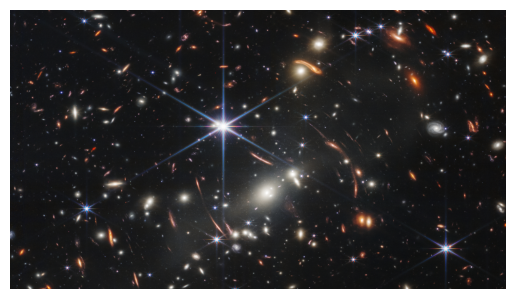

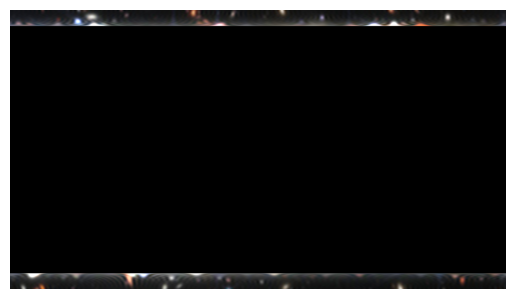

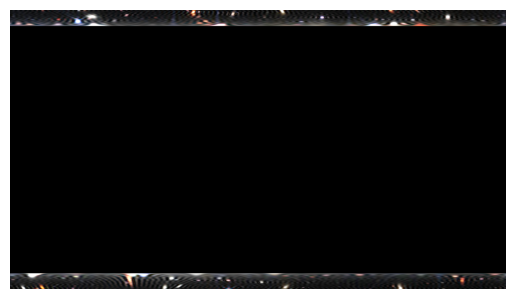

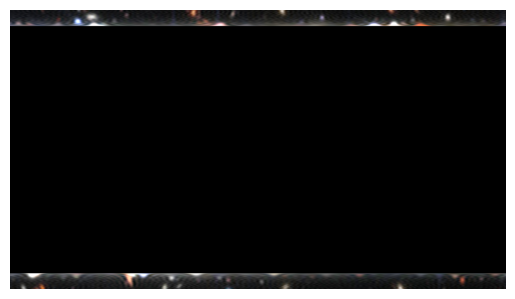

In [4]:
blurred = Image.open('stars_blurred.jpg')
noisy = Image.open('stars_noise.jpg')
both = Image.open('stars_both.jpg')

#apply the inverse filtering function
inverse_blurred = inverse_filtering(blurred, 51,5)
inverse_noisy = inverse_filtering(noisy, 51,5)
inverse_both = inverse_filtering(both,51,5)

# show images
plt.imshow(original)
plt.axis('off')
plt.show()

plt.imshow(inverse_blurred)
plt.axis('off')
plt.show()

plt.imshow(inverse_noisy)
plt.axis('off')
plt.show()

plt.imshow(inverse_both)
plt.axis('off')
plt.show()


#save images if necessary
# inverse_blurred.save('stars_inverse_blurred.jpg')
# inverse_noise.save('stars_inverse_noisy.jpg')
# inverse_both_save('stars_inverse_both.jpg')

## Evaluation: peak signal-to-noise ratio (PSNR)

In [5]:
def peak_signal_to_noise_ratio(original, restored):
    #larger the value, higher the quality of restored image
   
    original = np.array(original).astype(np.float64)
    restored = np.array(restored).astype(np.float64)

    
    #for 8-bit images, we set MAX = 255
    max = 255
    
    #calculating mse (mean square error)
    mse = np.sum((original-restored)**2) / original.size

    #if mse = 0: two images are the same
    if mse == 0:
        return (float('inf'))
    else:
        psnr = 10 * np.log10(max**2 / mse)
        return(psnr)

## Evaluation: Structural Similarity Index Measure

In [6]:
def structural_similarity_index_measure(original,restored, C1=0.01, C2=0.03, L=255):
    #range is [0,1], higher to value, the better the image quality
    
    original = np.array(original).astype(np.float64)
    restored = np.array(restored).astype(np.float64)

    mean_original = np.mean(original)
    mean_restored = np.mean(restored)

    var_original = np.var(original)
    var_restored = np.var(restored)

    covar = np.cov(original.flatten(), restored.flatten())[0, 1]

    ssim = ((2*mean_original*mean_restored + C1) * (2*covar + C2))/((mean_original**2 +mean_restored**2 + C1)*(var_original+var_restored+C2))

    return ssim

## Evaluation of Messy Images (Baseline for Comparison):

In [7]:
psnr_blurred = peak_signal_to_noise_ratio(original, blurred)
psnr_noisy = peak_signal_to_noise_ratio(original, noisy)
psnr_both = peak_signal_to_noise_ratio(original, both)

ssim_blurred = structural_similarity_index_measure(original, blurred)
ssim_noisy = structural_similarity_index_measure(original, noisy)
ssim_both = structural_similarity_index_measure(original, both)

print('Original to Messed Up Images')
print(f"original to blurry - PSNR: {psnr_blurred}")
print(f"original to noisy - PSNR: {psnr_noisy}")
print(f"original to both - PSNR: {psnr_both}")
print(f"original to blurry - SSIM: {ssim_blurred}")
print(f"original to noisy - SSIM: {ssim_noisy}")
print(f"original to both - SSIM: {ssim_both}")

Original to Messed Up Images
original to blurry - PSNR: 27.41145360820576
original to noisy - PSNR: 27.20096451599476
original to both - PSNR: 24.494670596631394
original to blurry - SSIM: 0.928489850287716
original to noisy - SSIM: 0.9375042235924705
original to both - SSIM: 0.8689478048131504


## Evaluation for Richardson-Lucy

In [8]:
rl_blurred = Image.open('rl_blurred.png')
rl_builtin_blurred = Image.open('rl_blurred_builtin.png')
rl_noisy = Image.open('rl_noisy.png')
rl_builtin_noisy = Image.open('rl_noisy_builtin.png')
rl_both = Image.open('rl_both.png')
rl_builtin_both = Image.open('rl_both_builtin.png')


psnr_rl_blurred = peak_signal_to_noise_ratio(original, rl_blurred)
psnr_rl_noisy = peak_signal_to_noise_ratio(original, rl_noisy)
psnr_rl_both = peak_signal_to_noise_ratio(original, rl_both)

ssim_rl_blurred = structural_similarity_index_measure(original, rl_blurred)
ssim_rl_noisy = structural_similarity_index_measure(original, rl_noisy)
ssim_rl_both = structural_similarity_index_measure(original, rl_both)


psnr_rl_blurred_builtin = peak_signal_to_noise_ratio(original, rl_builtin_blurred)
psnr_rl_noisy_builtin = peak_signal_to_noise_ratio(original, rl_builtin_noisy)
psnr_rl_both_builtin = peak_signal_to_noise_ratio(original, rl_builtin_both)

ssim_rl_blurred_builtin = structural_similarity_index_measure(original, rl_builtin_blurred)
ssim_rl_noisy_builtin = structural_similarity_index_measure(original, rl_builtin_noisy)
ssim_rl_both_builtin = structural_similarity_index_measure(original, rl_builtin_both)




print('blurred')
print(f"original to RL blurred - PSNR: {psnr_rl_blurred}")
print(f"original to RL builtin blurred - PSNR {psnr_rl_blurred_builtin}")
print(f"original to RL blurred - SSIM:: {ssim_rl_blurred}")
print(f"original to RL builtin blurred - SSIM:: {ssim_rl_blurred_builtin}")
print(f"delta PSNR RL Blurred: {psnr_rl_blurred-psnr_blurred}")
print(f"delta PSNR RL Blurred Bluitin: {psnr_rl_blurred_builtin-psnr_blurred}")
print(f"delta SSIM RL Blurred: {ssim_rl_blurred-ssim_blurred}")
print(f"delta SSIM RL Blurred Bluitin: {ssim_rl_blurred_builtin-ssim_blurred}")

print(f'\nnoisy')
print(f"original to RL noise - PSNR: {psnr_rl_noisy}")
print(f"original to RL builtin noise - PSNR: {psnr_rl_noisy_builtin}")

print(f"original to RL noise - SSIM:: {ssim_rl_noisy}")
print(f"original to RL builtin noise - SSIM:: {ssim_rl_noisy_builtin}")

print(f"delta PSNR RL Noisy: {psnr_rl_noisy-psnr_noisy}")
print(f"delta PSNR RL Noisy Bluitin: {psnr_rl_noisy_builtin-psnr_noisy}")
print(f"delta SSIM RL Noisy: {ssim_rl_noisy-ssim_noisy}")
print(f"delta SSIM RL Noisy Bluitin: {ssim_rl_noisy_builtin-ssim_noisy}")

print(f'\nboth')
print(f"original to RL both - PSNR: {psnr_rl_both}")
print(f"original to RL builtin both - PSNR: {psnr_rl_both_builtin}")

print(f"original to RL both - SSIM:: {ssim_rl_both}")
print(f"original to RL builtin both - SSIM:: {ssim_rl_both_builtin}")

print(f"delta PSNR RL Both: {psnr_rl_both-psnr_both}")
print(f"delta PSNR RL Both Bluitin: {psnr_rl_both_builtin-psnr_both}")
print(f"delta SSIM RL Both: {ssim_rl_both-ssim_both}")
print(f"delta SSIM RL Both Bluitin: {ssim_rl_both_builtin-ssim_both}")

blurred
original to RL blurred - PSNR: 27.006750992642566
original to RL builtin blurred - PSNR 27.00675132139022
original to RL blurred - SSIM:: 0.9270366423838667
original to RL builtin blurred - SSIM:: 0.9270366506300733
delta PSNR RL Blurred: -0.4047026155631954
delta PSNR RL Blurred Bluitin: -0.4047022868155423
delta SSIM RL Blurred: -0.0014532079038492851
delta SSIM RL Blurred Bluitin: -0.0014531996576426787

noisy
original to RL noise - PSNR: 24.334858245688746
original to RL builtin noise - PSNR: 24.33486028189053
original to RL noise - SSIM:: 0.8926681827476216
original to RL builtin noise - SSIM:: 0.8926682281973839
delta PSNR RL Noisy: -2.8661062703060125
delta PSNR RL Noisy Bluitin: -2.8661042341042275
delta SSIM RL Noisy: -0.044836040844848934
delta SSIM RL Noisy Bluitin: -0.04483599539508665

both
original to RL both - PSNR: 26.40058382471924
original to RL builtin both - PSNR: 26.40058382471924
original to RL both - SSIM:: 0.9174799342939521
original to RL builtin both -

## Evaluation for Wiener Method

In [10]:
wiener_blurred = Image.open('wiener_blurred.png')
wiener_builtin_blurred = Image.open('wiener_blurred_builtin.png')
wiener_noisy = Image.open('wiener_noisy.png')
wiener_builtin_noisy = Image.open('wiener_noisy_builtin.png')
wiener_both = Image.open('wiener_both.png')
wiener_builtin_both = Image.open('wiener_both_builtin.png')


psnr_wiener_blurred = peak_signal_to_noise_ratio(original, wiener_blurred)
psnr_wiener_noisy = peak_signal_to_noise_ratio(original, wiener_noisy)
psnr_wiener_both = peak_signal_to_noise_ratio(original, wiener_both)


ssim_wiener_blurred = structural_similarity_index_measure(original, wiener_blurred)
ssim_wiener_noisy = structural_similarity_index_measure(original, wiener_noisy)
ssim_wiener_both = structural_similarity_index_measure(original, wiener_both)


psnr_wiener_blurred_builtin = peak_signal_to_noise_ratio(original, wiener_builtin_blurred)
psnr_wiener_noisy_builtin = peak_signal_to_noise_ratio(original, wiener_builtin_noisy)
psnr_wiener_both_builtin = peak_signal_to_noise_ratio(original, wiener_builtin_both)

ssim_wiener_blurred_builtin = structural_similarity_index_measure(original, wiener_builtin_blurred)
ssim_wiener_noisy_builtin = structural_similarity_index_measure(original, wiener_builtin_noisy)
ssim_wiener_both_builtin = structural_similarity_index_measure(original, wiener_builtin_both)

print('blurred')
print(f"original to wiener blurred - PSNR: {psnr_wiener_blurred}")
print(f"original to wiener builtin blurred - PSNR {psnr_wiener_blurred_builtin}")
print(f"original to wiener blurred - SSIM:: {ssim_wiener_blurred}")
print(f"original to wiener builtin blurred - SSIM:: {ssim_wiener_blurred_builtin}")
print(f"delta PSNR wiener Blurred: {psnr_wiener_blurred-psnr_blurred}")
print(f"delta PSNR wiener Blurred Bluitin: {psnr_wiener_blurred_builtin-psnr_blurred}")
print(f"delta SSIM wiener Blurred: {ssim_wiener_blurred-ssim_blurred}")
print(f"delta SSIM wiener Blurred Bluitin: {ssim_wiener_blurred_builtin-ssim_blurred}")

print(f'\nnoisy')
print(f"original to wiener noise - PSNR: {psnr_wiener_noisy}")
print(f"original to wiener builtin noise - PSNR: {psnr_wiener_noisy_builtin}")

print(f"original to wiener noise - SSIM:: {ssim_wiener_noisy}")
print(f"original to wiener builtin noise - SSIM:: {ssim_wiener_noisy_builtin}")

print(f"delta PSNR wiener Noisy: {psnr_wiener_noisy-psnr_noisy}")
print(f"delta PSNR wiener Noisy Bluitin: {psnr_wiener_noisy_builtin-psnr_noisy}")
print(f"delta SSIM wiener Noisy: {ssim_wiener_noisy-ssim_noisy}")
print(f"delta SSIM wiener Noisy Bluitin: {ssim_wiener_noisy_builtin-ssim_noisy}")

print(f'\nboth')
print(f"original to wiener both - PSNR: {psnr_wiener_both}")
print(f"original to wiener builtin both - PSNR: {psnr_wiener_both_builtin}")

print(f"original to wiener both - SSIM:: {ssim_wiener_both}")
print(f"original to wiener builtin both - SSIM:: {ssim_wiener_both_builtin}")

print(f"delta PSNR wiener Both: {psnr_wiener_both-psnr_both}")
print(f"delta PSNR wiener Both Bluitin: {psnr_wiener_both_builtin-psnr_both}")
print(f"delta SSIM wiener Both: {ssim_wiener_both-ssim_both}")
print(f"delta SSIM wiener Both Bluitin: {ssim_wiener_both_builtin-ssim_both}")

blurred
original to wiener blurred - PSNR: 28.837310117182163
original to wiener builtin blurred - PSNR 27.30331836796713
original to wiener blurred - SSIM:: 0.9530041538610056
original to wiener builtin blurred - SSIM:: 0.9266176687988108
delta PSNR wiener Blurred: 1.425856508976402
delta PSNR wiener Blurred Bluitin: -0.10813524023863152
delta SSIM wiener Blurred: 0.024514303573289542
delta SSIM wiener Blurred Bluitin: -0.0018721814889052224

noisy
original to wiener noise - PSNR: 25.552120633658948
original to wiener builtin noise - PSNR: 31.894561936827035
original to wiener noise - SSIM:: 0.9013526277313265
original to wiener builtin noise - SSIM:: 0.9777933398299943
delta PSNR wiener Noisy: -1.648843882335811
delta PSNR wiener Noisy Bluitin: 4.693597420832276
delta SSIM wiener Noisy: -0.036151595861144026
delta SSIM wiener Noisy Bluitin: 0.04028911623752374

both
original to wiener both - PSNR: 26.00818962810532
original to wiener builtin both - PSNR: 26.335201363213358
original t

## Evaluation for Inverse Filtering

In [11]:
inverse_blurred = Image.open('inverse_blurred.jpg')
inverse_noisy = Image.open('inverse_noisy.jpg')
inverse_both = Image.open('inverse_both.jpg')

psnr_inverse_blurred = peak_signal_to_noise_ratio(original, inverse_blurred)
psnr_inverse_noisy = peak_signal_to_noise_ratio(original, inverse_noisy)
psnr_inverse_both = peak_signal_to_noise_ratio(original, inverse_both)

ssim_inverse_blurred = structural_similarity_index_measure(original, inverse_blurred)
ssim_inverse_noisy = structural_similarity_index_measure(original, inverse_noisy)
ssim_inverse_both = structural_similarity_index_measure(original, inverse_both)


print('blurred')
print(f"original to inverse blurred - PSNR: {psnr_inverse_blurred}")
print(f"original to inverse blurred - SSIM:: {ssim_inverse_blurred}")
print(f"delta PSNR inverse Blurred: {psnr_inverse_blurred-psnr_blurred}")
print(f"delta SSIM inverse Blurred: {ssim_inverse_blurred-ssim_blurred}")


print(f'\nnoisy')
print(f"original to inverse noise - PSNR: {psnr_inverse_noisy}")
print(f"original to inverse noise - SSIM:: {ssim_inverse_noisy}")
print(f"delta PSNR inverse Noisy: {psnr_inverse_noisy-psnr_noisy}")
print(f"delta SSIM inverse Noisy: {ssim_inverse_noisy-ssim_noisy}")


print(f'\nboth')
print(f"original to inverse both - PSNR: {psnr_inverse_both}")
print(f"original to inverse both - SSIM:: {ssim_inverse_both}")
print(f"delta PSNR inverse Both: {psnr_inverse_both-psnr_both}")
print(f"delta SSIM inverse Both: {ssim_inverse_both-ssim_both}")

blurred
original to inverse blurred - PSNR: 14.470773847091621
original to inverse blurred - SSIM:: -0.013950512134830772
delta PSNR inverse Blurred: -12.94067976111414
delta SSIM inverse Blurred: -0.9424403624225468

noisy
original to inverse noise - PSNR: 14.388664440748089
original to inverse noise - SSIM:: -0.013247329080415801
delta PSNR inverse Noisy: -12.81230007524667
delta SSIM inverse Noisy: -0.9507515526728864

both
original to inverse both - PSNR: 14.471902465736186
original to inverse both - SSIM:: -0.013346863542487769
delta PSNR inverse Both: -10.022768130895209
delta SSIM inverse Both: -0.8822946683556382
